# Backtest 2025 (Out-of-Sample)
Apply pretrained ML models from `models_PRETRAINED/` (trained on the full 2010–2024 dataset) to 2025 trade data for out-of-sample evaluation. This notebook tests whether the signal-based trade selection strategies generalise beyond the training period. Results here match the thesis exactly.

## Setup and Imports
Load utility functions from `analysis_utils` for data loading, trade analysis, and backtest reporting.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import joblib

from analysis_utils import (
    load_span,
    analyse_trades,
    compute_composite_signal,
    full_backtest_report,
)

from pathlib import Path
BASE_DIR = Path.cwd() # use this for Jupyter notebook
print(f"Base directory set to: {BASE_DIR}")

Base directory set to: c:\Users\Wang0\OneDrive\文档\UNSW OneDrive\Honours Thesis\code_DEMO


## Load and Merge 2025 Data
Load 2025 trade results from `backtest_results_PRECOMPUTED/` and signals from `vrp_signals_PRECOMPUTED/`, merge on ticker and open date, compute composite signals and normalised PnL, then isolate the short straddle 1-week strategy for model evaluation.

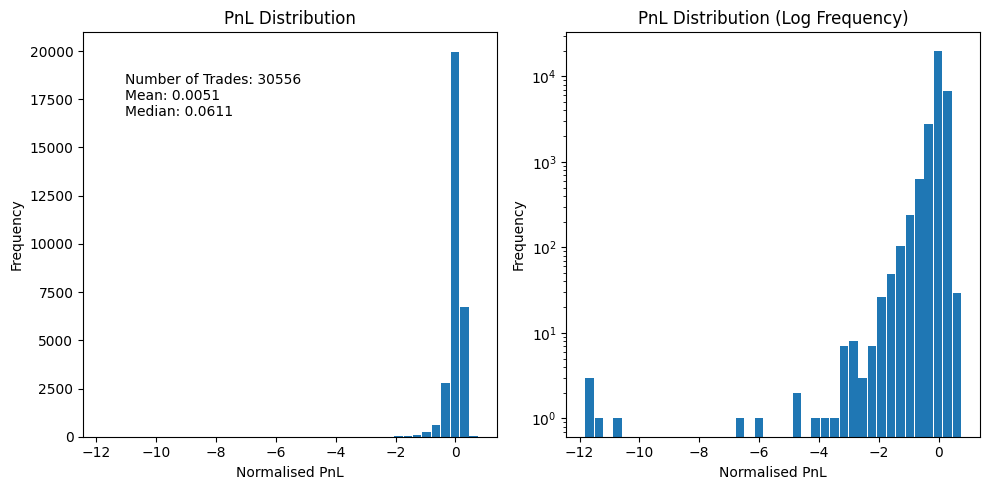

{'count': 30556.0,
 'mean': 0.005056244786828756,
 'std': 0.28731000423431396,
 'min': -11.828570365905762,
 '25%': -0.0434782924130559,
 '50%': 0.06112224422395229,
 '75%': 0.13235296681523323,
 'max': 0.7719298005104065,
 'positive_trades': 20452,
 'negative_trades': 9944}

In [2]:
# --- Load 2025 trades + signals and merge ---
start_month = "2025-01"
end_month   = "2025-12"

trades = load_span(BASE_DIR / "backtest_results_PRECOMPUTED", start_month, end_month, prefix="trades")
signals = load_span(BASE_DIR / "vrp_signals_PRECOMPUTED", start_month, end_month, prefix="signals")

# Rename trade_date to open_date for merging
signals.rename(columns={"trade_date": "open_date"}, inplace=True)

# Merge trades with signals
backtest_df = pd.merge(trades, signals, on=["ticker", "open_date"], how="left")

# Drop rows with missing rv30_cc
backtest_df = backtest_df.dropna(subset=["rvol30_cc"])

# Downcast float64 to float32 to save memory
float_cols = backtest_df.select_dtypes(include="float64").columns
backtest_df[float_cols] = backtest_df[float_cols].astype("float32")

# NOTE: we have multiple strategies for the same ticker and open_date,
# merge will automatically fill in the same signal values for each strategy, which is what we want

# Compute composite signals and PnL
compute_composite_signal(backtest_df)
backtest_df["pnl"] = backtest_df["exit_cashflow"] + backtest_df["entry_cashflow"]
backtest_df["pnl_norm"] = backtest_df["pnl"] / backtest_df["notional"].abs()

# Remove stock splits
# # GE trades entered between 2021-07-06 and 2021-07-30 due to stock split
# backtest_df = backtest_df[~((backtest_df["ticker"] == "GE") & (backtest_df["open_date"] >= "2021-07-06") & (backtest_df["open_date"] <= "2021-07-30"))]

# Split by strategy
strats = ["short_straddle_hold", "short_straddle_1w", "long_call_butterfly_hold"]
backtest_df_1 = backtest_df[backtest_df["strategy"] == "short_straddle_hold"]
backtest_df_2 = backtest_df[backtest_df["strategy"] == "short_straddle_1w"]
backtest_df_3 = backtest_df[backtest_df["strategy"] == "long_call_butterfly_hold"]

# Analyse the primary strategy
df = backtest_df_2
analyse_trades(df)

## Prepare Data
Extract the same signal features used during training and define the classification target (top quartile PnL). The target is only used for reference — model inference does not require labels.

In [3]:
# Build feature matrix for model inference
df_ml = df.copy() 

features = ["iv30_rv30", "ts_slope_45", "avg_underlying_volume", "daily_option_volume"]

# Use all signal features
features = df_ml.columns[15:33].tolist()

print(features)

# Define classification target (top quartile = positive class)
threshold = df_ml["pnl_norm"].quantile(0.75)
df_ml["target"] = (df_ml["pnl_norm"] >= threshold).astype(int)

X = df_ml[features]
y = df_ml["target"]  # we actually never need this

print(f"Ratio of positive to negative PnL: {sum(df_ml['pnl_norm'] > 0)} : {sum(df_ml['pnl_norm'] <= 0)}")
print(f"Absolute PnL threshold: {threshold:.4f}")  
print(X.shape)

['rvol30_yz', 'rvol30_cc', 'ivar30', 'dte0', 'atm_iv0', 'atm_iv30', 'atm_iv45', 'atm_iv60', 'avg_underlying_volume', 'daily_option_volume', 'market_iv30', 'iv30_rv30', 'fwd_var_30_60', 'fwd_iv_30_60', 'fwd_factor_30_60', 'ts_slope_30', 'ts_slope_45', 'ts_slope_60']
Ratio of positive to negative PnL: 20452 : 10104
Absolute PnL threshold: 0.1324
(30556, 18)


## Load Pretrained Models
Load the decision tree, anti-tree, and random forest models from `models_PRETRAINED/`. These were trained on the full 2010–2024 dataset in `backtest_analysis.ipynb`.

In [8]:
best_tree = joblib.load(BASE_DIR / "models_PRETRAINED" / "best_tree.joblib")
best_anti_tree = joblib.load(BASE_DIR / "models_PRETRAINED" / "best_anti_tree.joblib")
best_forest = joblib.load(BASE_DIR / "models_PRETRAINED" / "best_forest.joblib")

## Simple Tree Model
Apply the pretrained decision tree to 2025 data, keeping only the top 10% most confident predictions. Evaluate with a full backtest report including Monte Carlo simulation.

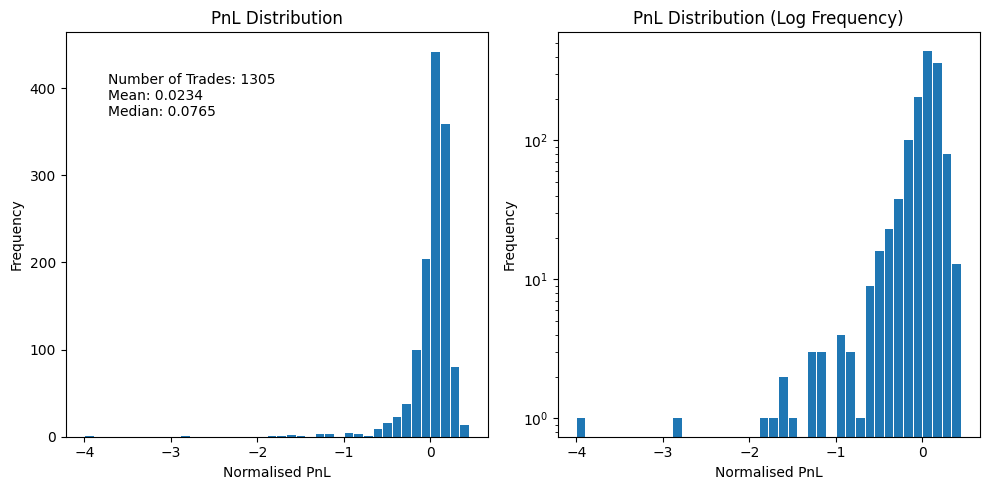


  BACKTEST SUMMARY

RISK METRICS
   ann_return_%                 31.78
   ann_volatility_%             11.95
   sharpe_ratio                 2.241
   win_rate_%                   59.85
   avg_daily_return_%           0.1124
   best_day_%                   4.95
   worst_day_%                  -3.94

MAX DRAWDOWN
   max_drawdown_$               -19.92
   max_drawdown_%               -14.66
   peak_date                    2025-10-03
   trough_date                  2025-10-24
   recovery_date                Not recovered
   drawdown_duration_days       21
   recovery_duration_days       None

MONTE CARLO (next 252 days * 10000 sims)
   start_equity                 100
   median_final_equity          131.69
   mean_final_equity            132.68
   p5_final_equity              108.05
   p95_final_equity             160.52
   prob_profit_%                99.0
   prob_drawdown_20pct_%        0.0
   expected_max_dd_%            -7.08


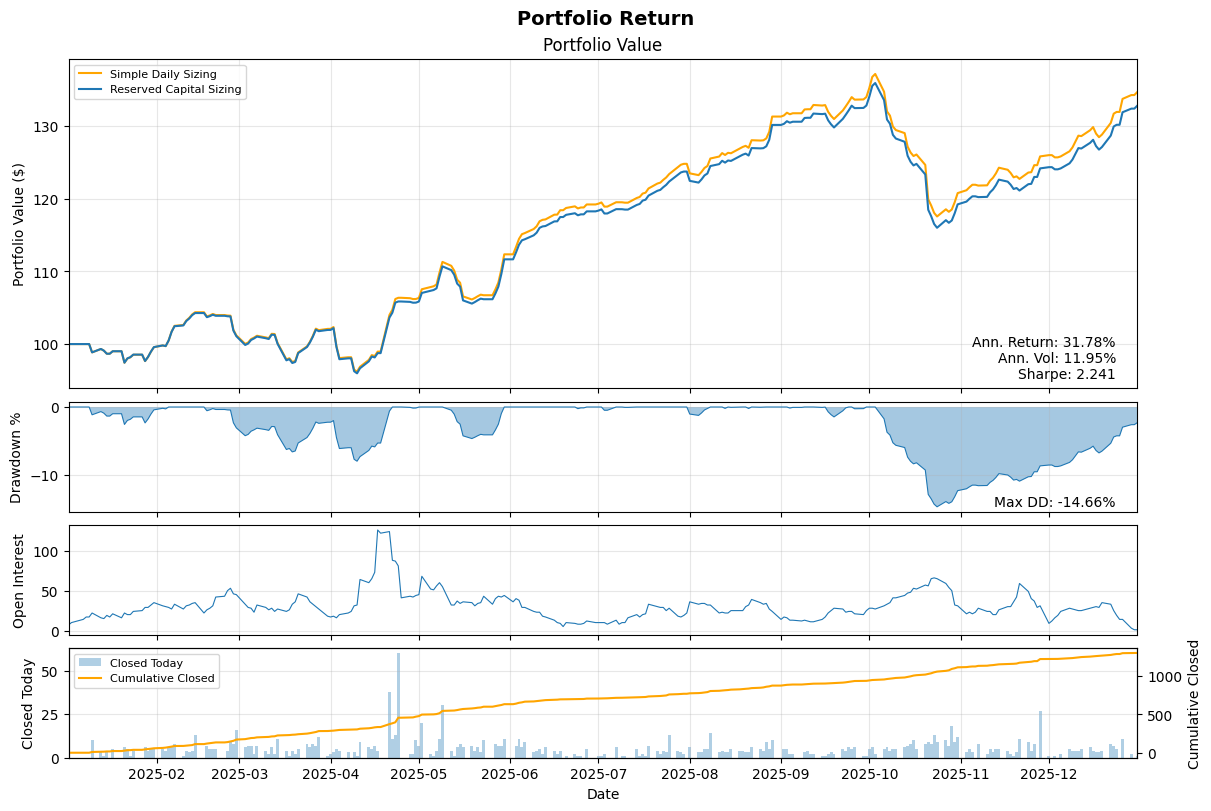

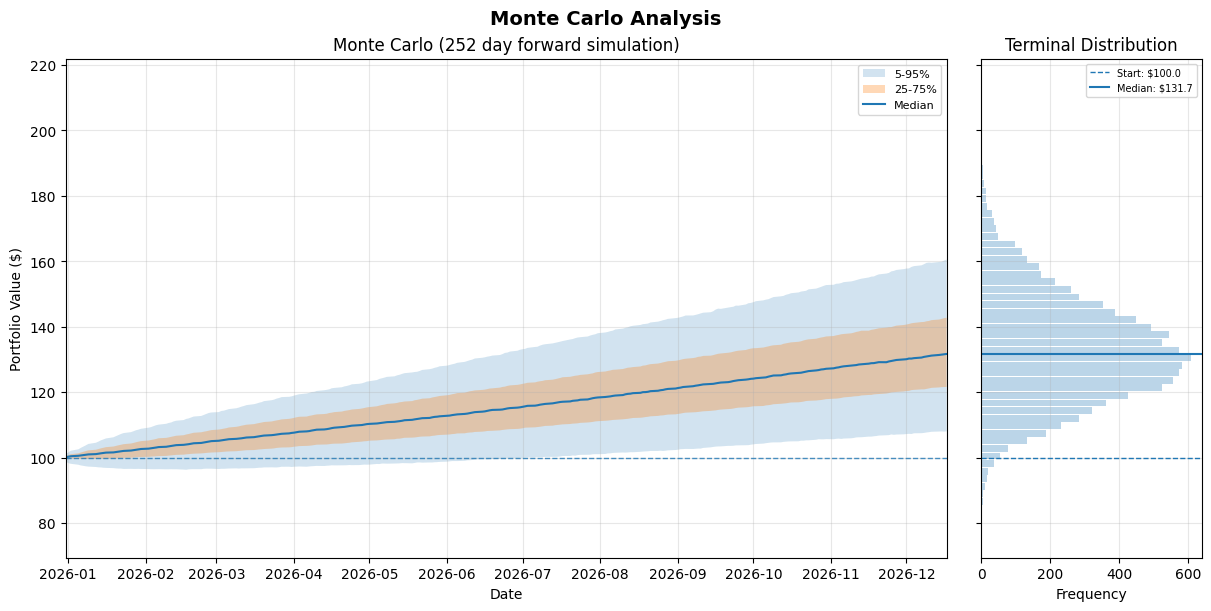

In [5]:
# Decision tree: keep top 10% predictions
y_prob = best_tree.predict_proba(X)[:, 1]
threshold = np.quantile(y_prob, 0.9)
filtered_df = df_ml[y_prob > threshold]
analyse_trades(filtered_df)
results = full_backtest_report(filtered_df, 0.01, mc_sims=10000)

## Simple Tree and Rejection Model
Combine the positive tree (keep top 20%) with the anti-tree (reject bottom 20%) for a two-stage filter. This approach selects promising trades while simultaneously removing likely losers.

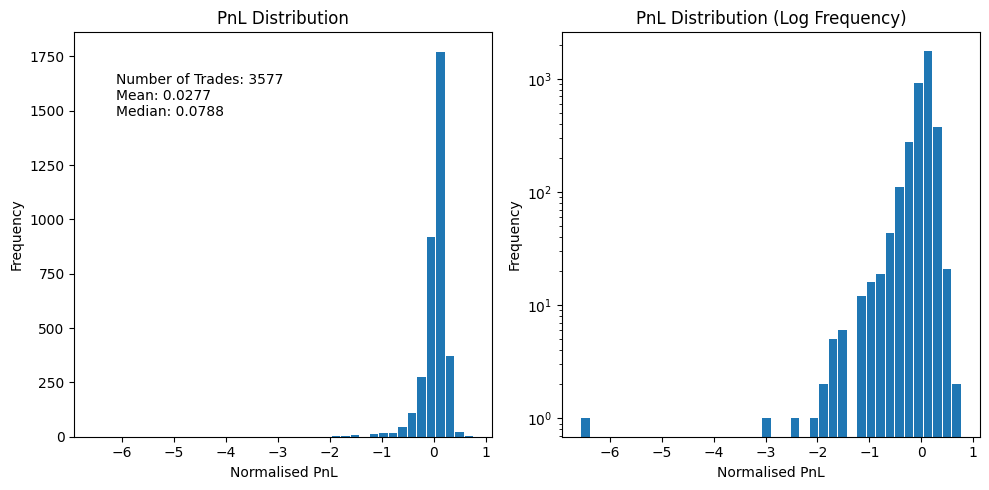


  BACKTEST SUMMARY

RISK METRICS
   ann_return_%                 130.01
   ann_volatility_%             32.86
   sharpe_ratio                 3.804
   win_rate_%                   58.3
   avg_daily_return_%           0.3518
   best_day_%                   17.48
   worst_day_%                  -9.44

MAX DRAWDOWN
   max_drawdown_$               -30.85
   max_drawdown_%               -18.84
   peak_date                    2025-09-03
   trough_date                  2025-10-16
   recovery_date                2025-11-26
   drawdown_duration_days       43
   recovery_duration_days       41

MONTE CARLO (next 252 days * 10000 sims)
   start_equity                 100
   median_final_equity          228.46
   mean_final_equity            242.07
   p5_final_equity              138.07
   p95_final_equity             397.81
   prob_profit_%                99.7
   prob_drawdown_20pct_%        1.2
   expected_max_dd_%            -14.6


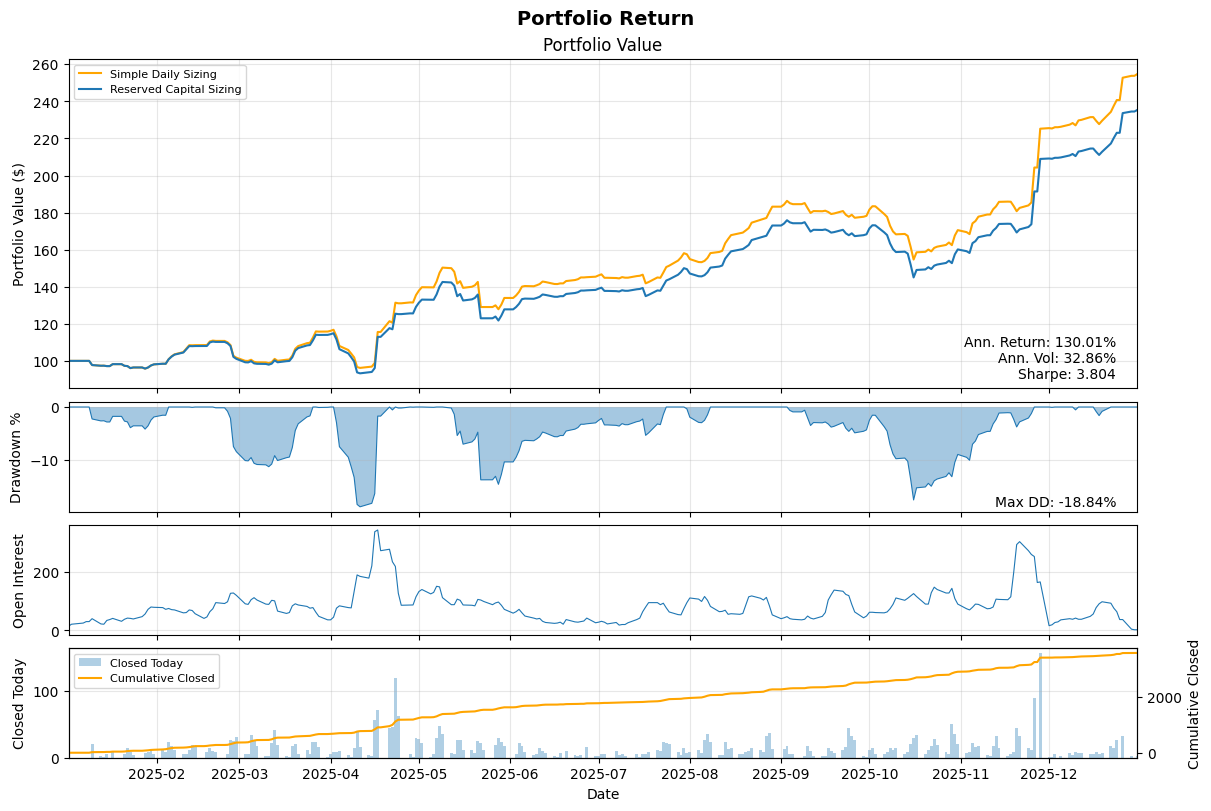

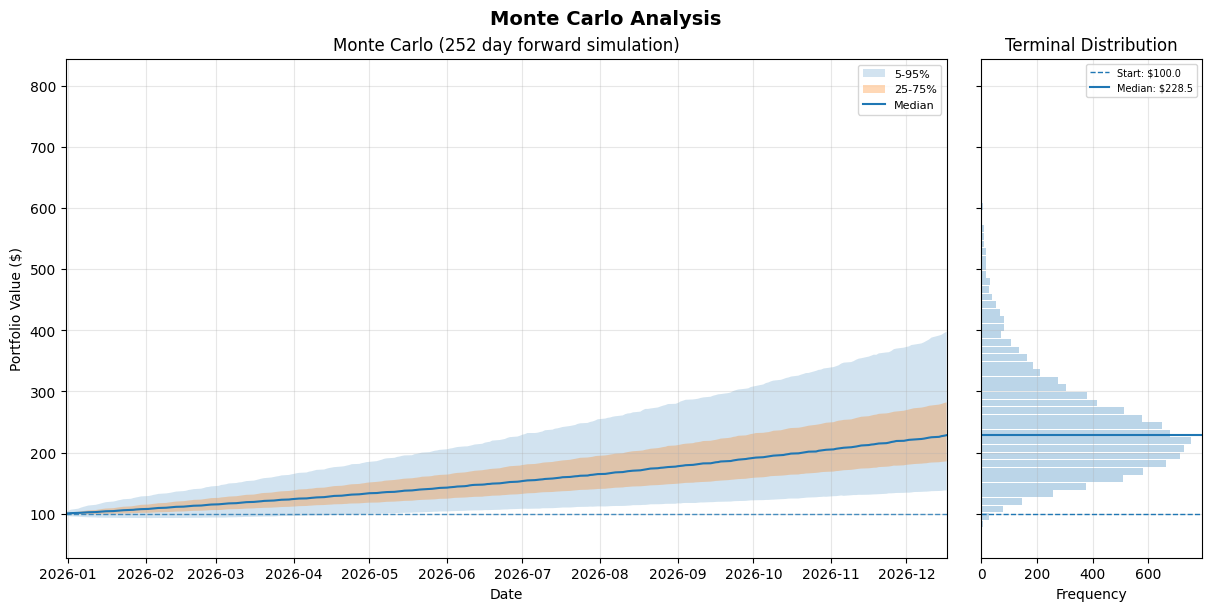

In [6]:
# Combined tree filter: keep top 20% by positive model, remove bottom 20% by negative model
y_prob = best_tree.predict_proba(X)[:, 1]
z_prob = best_anti_tree.predict_proba(X)[:, 1]

threshold = np.quantile(y_prob, 0.8)       # keep top 20%
anti_threshold = np.quantile(z_prob, 1 - 0.2)  # remove bottom 20%
filtered_df = df_ml[(z_prob < anti_threshold) & (y_prob > threshold)]

analyse_trades(filtered_df)
results = full_backtest_report(filtered_df, 0.01, mc_sims=10000)

## Forest Model
Apply the pretrained random forest to 2025 data, keeping only the top 10% most confident predictions. Compare out-of-sample performance against the decision tree approaches above.

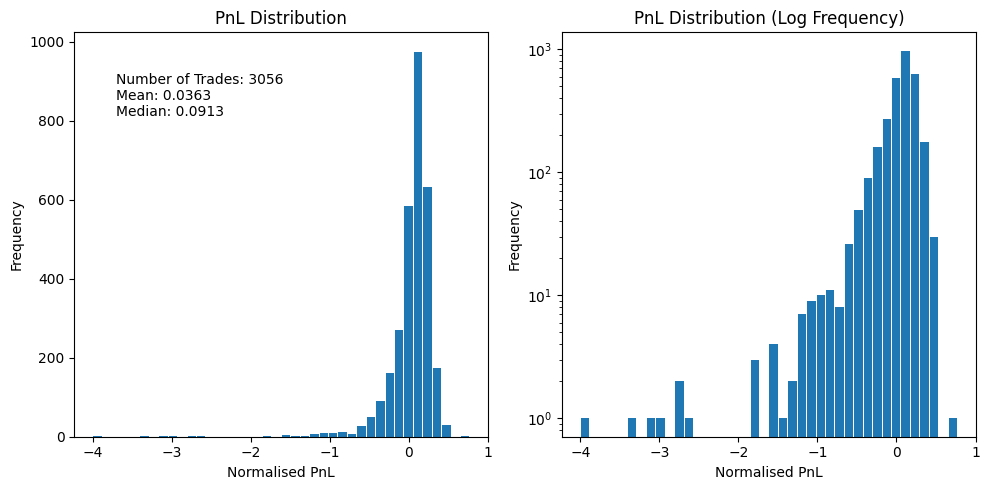


  BACKTEST SUMMARY

RISK METRICS
   ann_return_%                 162.91
   ann_volatility_%             27.1
   sharpe_ratio                 5.828
   win_rate_%                   57.14
   avg_daily_return_%           0.3984
   best_day_%                   15.01
   worst_day_%                  -4.58

MAX DRAWDOWN
   max_drawdown_$               -49.92
   max_drawdown_%               -20.15
   peak_date                    2025-10-02
   trough_date                  2025-10-24
   recovery_date                2025-11-26
   drawdown_duration_days       22
   recovery_duration_days       33

MONTE CARLO (next 252 days * 10000 sims)
   start_equity                 100
   median_final_equity          260.98
   mean_final_equity            272.36
   p5_final_equity              173.18
   p95_final_equity             411.18
   prob_profit_%                100.0
   prob_drawdown_20pct_%        0.0
   expected_max_dd_%            -9.64


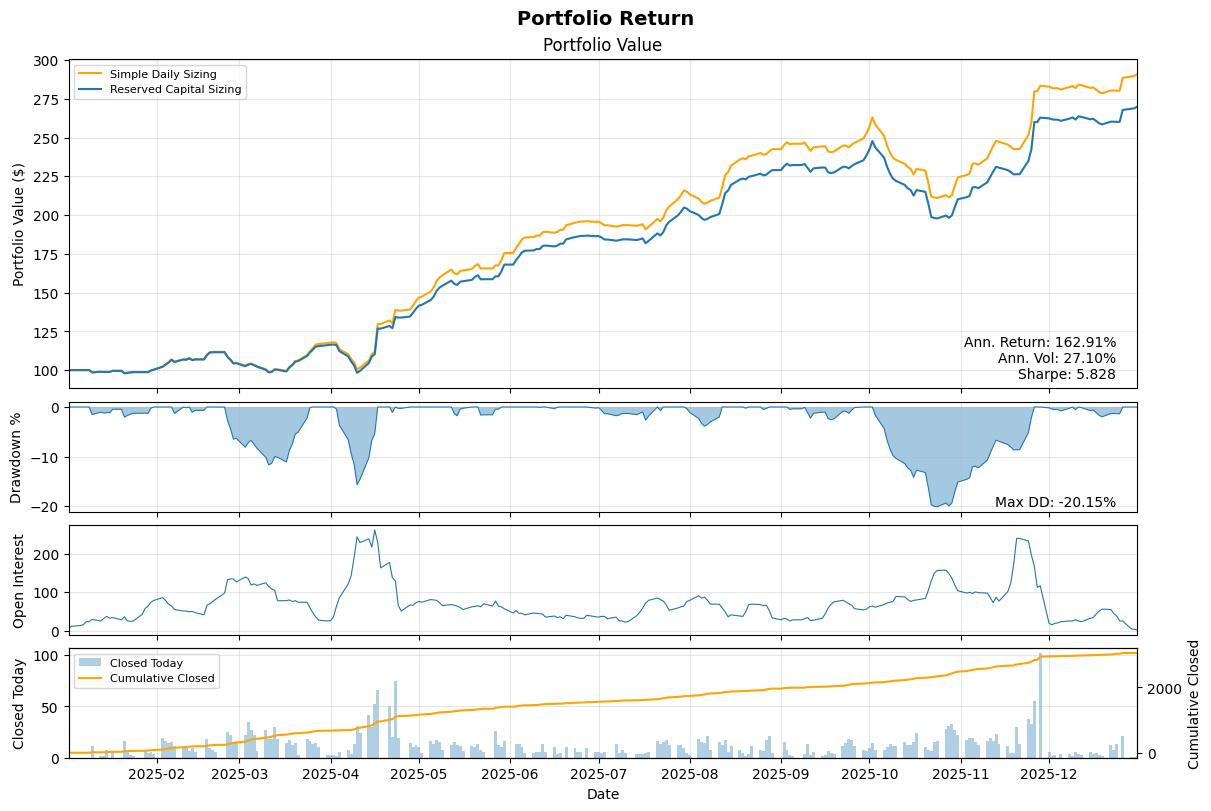

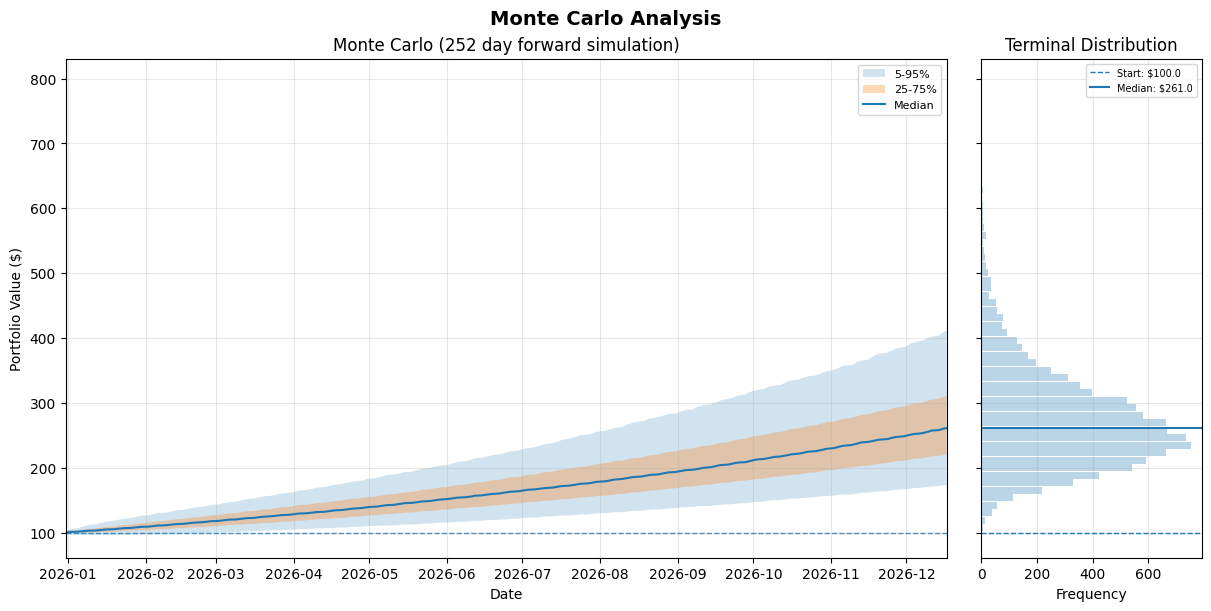

In [7]:
# Random forest: keep top 10% predictions
y_prob = best_forest.predict_proba(X)[:, 1]
threshold = np.quantile(y_prob, 0.9)
filtered_df = df_ml[y_prob > threshold]
analyse_trades(filtered_df)
results = full_backtest_report(filtered_df, 0.01, mc_sims=10000)